# Build 04-03 — The third estimator: regression adjustment, and why it fails twice  ·  P7

**Where this sits.** Same middle leg as 04-01 (RDD) and 04-02 (SHAP-DiD) — **Effect Estimation**.
P7 (Imbens & Wooldridge, 2009) catalogues *five* ways to identify a treatment effect from
observational data; this notebook runs the one the previous two did **not**:

> **Regression adjustment under unconfoundedness** — fit a logistic regression of the outcome on a
> **treatment dummy T** plus covariates X, and read the treatment effect off the coefficient on T.

It is the estimator a reviewer will ask about first, because it is the most familiar one. The honest
finding of this notebook is that **it does not work here — and the two different ways it breaks are
each an independent re-confirmation of the SFP structure.** A negative result, reported as evidence.

### The model (logit / log-odds)

Let `p(T,X) = P(Y=1 | T,X)` be the probability of total loss. Logistic regression models the
**log-odds** as linear:

```
log( p/(1−p) )  =  γ₀ + γ₁·T + γ₂·X
```

Holding X fixed and differencing T=1 against T=0, everything but γ₁ cancels, so

```
log( odds(T=1) / odds(T=0) )  =  γ₁      ⇒   ODDS RATIO  OR = exp(γ₁)
```

`exp(γ₁)` is the factor by which treatment multiplies the odds of total loss, **conditional on X**.
Two tests accompany it, and `statsmodels` returns both for free:

- **Wald test** of `H₀: γ₁ = 0` — `z = γ̂₁ / SE(γ̂₁)`, two-sided p from `N(0,1)`.
- **Likelihood-ratio test** — refit *without* T; `LR = −2(ℓ_restricted − ℓ_full) ~ χ²₁`. Asks whether
  adding T improves fit **beyond** what X already explains. (The restricted model keeps **all** of X;
  it drops only T — so this is not "throwing away covariate information", it is isolating T's
  *incremental* contribution.)

### The one thing that decides everything: what is T?

`exp(γ₁)` is only a **causal** odds ratio if the identifying assumption holds:

> **Unconfoundedness + overlap** — treated and control units are comparable given X
> (`T ⊥ potential outcomes | X`), and both T=0 and T=1 actually occur at every X.

There are two natural readings of "the FTTL treatment", and **each violates a different half of this
assumption** — in a way we have already met elsewhere in the project:

| reading of T | Y | which half breaks | the wall (already seen) |
|---|---|---|---|
| **A — the scrap *decision*** (`decision = 1`) | observed outcome | **overlap** | forced labels + positivity dead at τ (04-01 / mitigation) |
| **B — the FTTL *era/cohort*** (ML era vs pre-ML) | total-loss label | **unconfoundedness** | market drift = the parallel-trends confound (04-02) |

The notebook runs both, in full, and lets the numbers show the wall. That is more convincing than
asserting the estimator is inapplicable.

### Setup — house style, data, covariates

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")   # statsmodels is chatty on perfect separation — we detect it ourselves

ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "synthetic" / "run.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "src" / "data" / "synthetic"))
from config import DECISION_RULES
SCRAP_THRESHOLD = DECISION_RULES['v2']['regimes'][0]['threshold']

import statsmodels.api as sm
from scipy.stats import chi2
import figstyle
figstyle.apply()

GEN    = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet"
claims = pd.read_parquet(GEN / "claims_all.parquet")
dates  = pd.to_datetime(claims["claim_date"])

# core numeric covariates X — kept legible on purpose (a 86-dim one-hot Logit obscures the point)
XCOLS  = ["vehicle_age_years", "mileage", "driver_age", "repair_to_value_ratio",
          "vehicle_value", "repair_estimate_gbp", "report_delay_days"]
MARKET = "used_car_price_index"     # the market-shift signal — held out, then added, in reading B

def zscore(frame: pd.DataFrame) -> pd.DataFrame:
    # Standardise covariates for numerical stability. Scaling X changes neither γ₁ nor its p-value
    # (T is binary and unscaled); it only steadies the optimiser and the covariate SEs.
    return (frame - frame.mean()) / frame.std(ddof=0)

print(f"statsmodels {sm.__version__}  ·  {len(claims):,} claims  ·  covariates: {XCOLS}")

statsmodels 0.14.6  ·  70,000 claims  ·  covariates: ['vehicle_age_years', 'mileage', 'driver_age', 'repair_to_value_ratio', 'vehicle_value', 'repair_estimate_gbp', 'report_delay_days']


In [2]:
def _fit(y, X):
    # Newton is fast but inverts the Hessian, which goes singular under perfect separation; fall
    # back to BFGS, which still returns the (diverging) coefficient instead of erroring.
    try:
        return sm.Logit(np.asarray(y), X).fit(disp=0, maxiter=300)
    except Exception:
        return sm.Logit(np.asarray(y), X).fit(method="bfgs", disp=0, maxiter=300)

def fit_logit(y, T, Xdf, label):
    # Fit  logit(Y) ~ T + X , return the odds ratio on T with Wald + LR tests. Flags perfect separation
    # — which shows up EITHER as a huge γ₁/SE OR as a non-finite SE (singular Hessian). Both mean the
    # treatment effect is not identified.
    Xfull = sm.add_constant(pd.concat([pd.Series(np.asarray(T), name="T", index=Xdf.index), Xdf], axis=1))
    full  = _fit(y, Xfull)
    rest  = _fit(y, sm.add_constant(Xdf))          # restricted: drop ONLY T (keep all of X)
    g1     = float(full.params["T"])
    se     = float(full.bse["T"])
    wald_p = float(full.pvalues["T"])
    lr     = 2.0 * (full.llf - rest.llf)
    separated = (not np.isfinite(se)) or se > 5 or abs(g1) > 10
    return dict(label=label, gamma1=g1, OR=float(np.exp(g1)), se=se, wald_p=wald_p,
                lr_chi2=float(lr), lr_p=float(chi2.sf(lr, 1)), separated=bool(separated), n=int(len(y)))

def show(r):
    tag = "  ⚠ PERFECT SEPARATION — T predicts Y deterministically; γ₁ not identified" if r["separated"] else ""
    se_s = "inf/nan" if not np.isfinite(r["se"]) else f"{r['se']:.3g}"
    print(f"{r['label']}")
    print(f"    n={r['n']:,}   γ₁={r['gamma1']:+.3f}   OR=exp(γ₁)={r['OR']:.3g}   SE={se_s}")
    print(f"    Wald p={r['wald_p']:.3g}   LR χ²={r['lr_chi2']:.1f} (p={r['lr_p']:.3g}){tag}")

## Reading A — T = the scrap *decision*.  The overlap wall.

The most literal reading: the treatment **is** being fast-tracked. `T = model_v2a_decision`, and the
outcome is the observed label. We expect the odds ratio to be enormous — and that expectation is the
problem, not the finding.

In [3]:
V     = "v2a"
era   = dates.dt.year >= 2022
sub   = claims[era].copy()
T     = sub[f"model_{V}_decision"].to_numpy()
y     = sub[f"model_{V}_observed_outcome"].astype(int)
Xz    = zscore(sub[XCOLS])

print(f"era rows {len(sub):,}   scrapped (T=1): {int(T.sum())}")
print(f"  P(Y=1 | T=1) = {y[T==1].mean():.3f}   ← FORCED: scrapped ⇒ recorded as total loss")
print(f"  P(Y=1 | T=0) = {y[T==0].mean():.3f}\n")

A = fit_logit(y, T, Xz, "A: logit(observed outcome) ~ T + X")
show(A)
print("\n  Why: every scrapped car has Y=1 by construction, so T=1 ⇒ Y=1 with no exceptions.")
print("  The likelihood is maximised by pushing γ₁ → +∞; the 'odds ratio' and its Wald test are")
print("  numerical artefacts, not an effect. (The LR test still 'rejects', which is exactly how this")
print("  failure MASQUERADES as a strong result to anyone not watching the standard error.)")

era rows 23,225   scrapped (T=1): 124
  P(Y=1 | T=1) = 1.000   ← FORCED: scrapped ⇒ recorded as total loss
  P(Y=1 | T=0) = 0.158

A: logit(observed outcome) ~ T + X
    n=23,225   γ₁=+12.689   OR=exp(γ₁)=3.24e+05   SE=90.5
    Wald p=0.888   LR χ²=59.0 (p=1.55e-14)  ⚠ PERFECT SEPARATION — T predicts Y deterministically; γ₁ not identified

  Why: every scrapped car has Y=1 by construction, so T=1 ⇒ Y=1 with no exceptions.
  The likelihood is maximised by pushing γ₁ → +∞; the 'odds ratio' and its Wald test are
  numerical artefacts, not an effect. (The LR test still 'rejects', which is exactly how this
  failure MASQUERADES as a strong result to anyone not watching the standard error.)


In [4]:
# The obvious repair — restrict to honestly-labelled rows — removes the treatment itself.
honest = T == 0
print(f"repair attempt: keep only garage-verified rows (T=0) so labels are trustworthy")
print(f"  kept: {int(honest.sum()):,} rows — ALL with T=0.  Treated units retained: {int((T[honest]==1).sum())}")
print( "  ⇒ no treatment variation left ⇒ γ₁ is inestimable.\n")
print("This is the OVERLAP failure, in regression form. It is the SAME fact as:")
print(f"  · positivity dead at τ (04-01 / mitigation): above τ = {SCRAP_THRESHOLD}, garage rows = 0;")
print( "  · why IPS cannot reweight the scrapped region and RDD (a LOCAL design) exists at all.")
print( "Reading A is not a bug to fix — it is the forced-label structure reasserting itself.")

repair attempt: keep only garage-verified rows (T=0) so labels are trustworthy
  kept: 23,101 rows — ALL with T=0.  Treated units retained: 0
  ⇒ no treatment variation left ⇒ γ₁ is inestimable.

This is the OVERLAP failure, in regression form. It is the SAME fact as:
  · positivity dead at τ (04-01 / mitigation): above τ = 0.872, garage rows = 0;
  · why IPS cannot reweight the scrapped region and RDD (a LOCAL design) exists at all.
Reading A is not a bug to fix — it is the forced-label structure reasserting itself.


## Reading B — T = the FTTL *era*.  The unconfoundedness wall.

The second reading treats the **regime** as the intervention: `T = 1` for the ML era (2022+, claims
routed by the model), `T = 0` for the pre-ML era (≤2021, human handlers). The outcome is the total-loss
label of each era. This one **converges** and returns a clean, significant-looking odds ratio — which
is precisely the trap.

Two things are wrong, and both are observable:

1. **Y is not the same measurement across T.** Pre-ML Y is `pre_ml_label` (a human decision); ML-era Y
   is `model_v2a_observed_outcome` (an SFP-contaminated model log). A difference in Y across T is partly
   a change in *what Y means*, not a treatment effect on a fixed outcome — the selective-labels problem.
2. **The era coincides with a market shift.** 2020–23 moved `used_car_price_index`. If adjusting for
   that single covariate swings γ₁, the "effect" is riding a confounder, and unconfoundedness is not
   credible.

In [5]:
pre, post = dates.dt.year <= 2021, dates.dt.year >= 2022
ylab = pd.Series(index=claims.index, dtype=float)
ylab[pre]  = claims.loc[pre,  "pre_ml_label"]                    # human-era label
ylab[post] = claims.loc[post, "model_v2a_observed_outcome"]      # contaminated model-log label
keep = (pre | post) & ylab.notna() & claims[XCOLS + [MARKET]].notna().all(axis=1)

sub  = claims[keep]
Tb   = post[keep].astype(int).to_numpy()
yb   = ylab[keep].astype(int)
print(f"rows {len(sub):,}   ML-era (T=1): {int(Tb.sum()):,}   pre-ML (T=0): {int((Tb==0).sum()):,}")
print(f"  market index: pre-ML mean {sub.loc[Tb==0, MARKET].mean():.2f}  vs  ML-era mean "
      f"{sub.loc[Tb==1, MARKET].mean():.2f}   ← the eras differ in the market, not just the routing\n")

B1 = fit_logit(yb, Tb, zscore(sub[XCOLS]),            "B1: Y ~ T + X            (market held OUT)")
B2 = fit_logit(yb, Tb, zscore(sub[XCOLS + [MARKET]]), "B2: Y ~ T + X + market   (confound adjusted)")
show(B1); print(); show(B2)

swing = B2["gamma1"] - B1["gamma1"]
print(f"\n  γ₁ swing on adding ONE covariate (market index): {B1['gamma1']:+.3f} → {B2['gamma1']:+.3f}"
      f"   (Δ = {swing:+.3f}, {abs(swing)/abs(B1['gamma1']):.0%} of the estimate)")
print( "  A causal effect should be STABLE to adjusting for a pre-treatment covariate. This much")
print( "  movement is the observable signature of confounding — unconfoundedness is not credible here.")
print( "  (Note also OR < 1: the ML era shows LOWER total-loss odds given X — implausible as a real")
print( "  FTTL effect, and a hint that Y itself changed meaning across the regime.)")

rows 70,000   ML-era (T=1): 23,225   pre-ML (T=0): 46,775
  market index: pre-ML mean 1.04  vs  ML-era mean 1.19   ← the eras differ in the market, not just the routing

B1: Y ~ T + X            (market held OUT)
    n=70,000   γ₁=-0.194   OR=exp(γ₁)=0.824   SE=0.0294
    Wald p=4.8e-11   LR χ²=43.8 (p=3.55e-11)

B2: Y ~ T + X + market   (confound adjusted)
    n=70,000   γ₁=-0.272   OR=exp(γ₁)=0.762   SE=0.0389
    Wald p=2.38e-12   LR χ²=49.3 (p=2.19e-12)

  γ₁ swing on adding ONE covariate (market index): -0.194 → -0.272   (Δ = -0.079, 41% of the estimate)
  A causal effect should be STABLE to adjusting for a pre-treatment covariate. This much
  movement is the observable signature of confounding — unconfoundedness is not credible here.
  (Note also OR < 1: the ML era shows LOWER total-loss odds given X — implausible as a real
  FTTL effect, and a hint that Y itself changed meaning across the regime.)


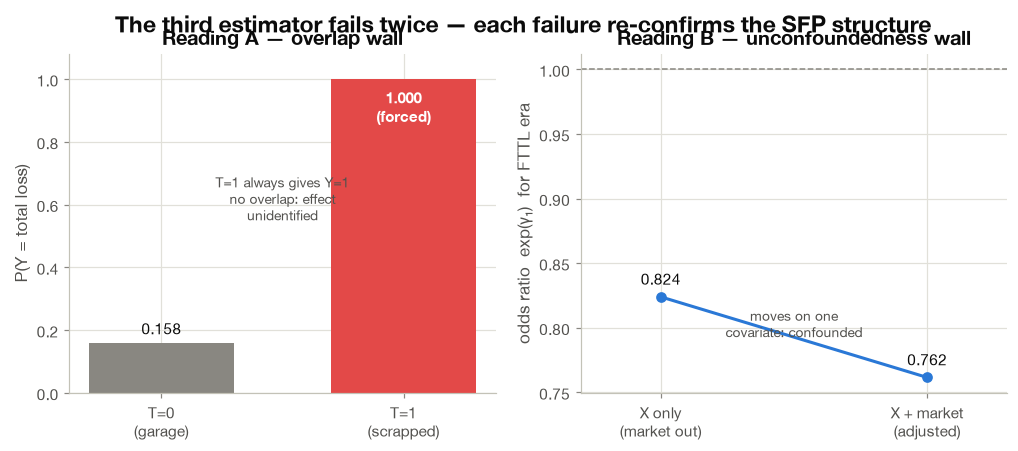

In [6]:
# ── Figure — the two walls, side by side ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=figstyle.FIG_2)

# Left — Reading A: the forced-label separation (P(Y=1) by T)
ax = axes[0]
rates = [y[T == 0].mean(), y[T == 1].mean()]
ax.bar([0, 1], rates, color=[figstyle.NEUTRAL, figstyle.CAUTION], width=0.6)
ax.set_xticks([0, 1]); ax.set_xticklabels(["T=0\n(garage)", "T=1\n(scrapped)"])
ax.set_ylim(0, 1.08); ax.set_ylabel("P(Y = total loss)")
ax.set_title("Reading A — overlap wall")
ax.annotate("1.000\n(forced)", xy=(1, 1.0), xytext=(0, -28), textcoords="offset points",
            ha="center", color="white", fontsize=10, fontweight="bold")
ax.annotate(f"{rates[0]:.3f}", xy=(0, rates[0]), xytext=(0, 6), textcoords="offset points",
            ha="center", color=figstyle.INK, fontsize=10)
ax.annotate("T=1 always gives Y=1\nno overlap: effect\nunidentified", xy=(0.5, 0.55), ha="center",
            color=figstyle.INK_SOFT, fontsize=9)

# Right — Reading B: OR fragility to the market covariate
ax = axes[1]
labels = ["X only\n(market out)", "X + market\n(adjusted)"]
ors    = [B1["OR"], B2["OR"]]
ax.plot([0, 1], ors, marker="o", color=figstyle.PRIMARY)
ax.axhline(1.0, color=figstyle.MUTED, lw=1.0, ls="--")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_xlim(-0.3, 1.3); ax.set_ylabel("odds ratio  exp(γ₁)  for FTTL era")
ax.set_title("Reading B — unconfoundedness wall")
for xp, orv in zip([0, 1], ors):
    ax.annotate(f"{orv:.3f}", xy=(xp, orv), xytext=(0, 8), textcoords="offset points",
                ha="center", color=figstyle.INK, fontsize=10)
ax.annotate("moves on one\ncovariate: confounded", xy=(0.5, np.mean(ors)), ha="center",
            color=figstyle.INK_SOFT, fontsize=9)

fig.suptitle("The third estimator fails twice — each failure re-confirms the SFP structure")
figstyle.save(fig, "04_03_logit_two_walls"); plt.show()

## Verdict — where this estimator belongs, and why its failure is evidence

### As an `EffectEstimator` (the app layer)

Regression adjustment is the **third** `EffectEstimator`, beside `RDDEstimator` (04-01) and
`ShapDiDEstimator` (04-02). Its ABC contract is what makes the negative result *automatic* rather than
a matter of the analyst's honesty:

| method | for this estimator |
|---|---|
| `assumptions()` | unconfoundedness (`T ⊥ potential outcomes | X`) **and** overlap |
| `falsify()` | **overlap test** (does every X region contain both T=0 and T=1?) → **fails in reading A**; **covariate-sensitivity test** (does γ₁ move when a pre-treatment covariate is added?) → **fails in reading B** |
| `estimate()` | `exp(γ₁)`, Wald p, LR p — **refused** (or demoted to "not identified") because `falsify()` did not pass |

`statsmodels.Logit` supplies `exp(γ₁)`, the Wald p-value, and the LR statistic directly — so the
**code is trivial; the identification is the whole problem.** (This is what `statsmodels` is in the
analysis env for; 04-02 used a bootstrap instead because HHI is a set-level statistic with no
coefficient to test.)

### Why the two failures are worth a chapter

They are not the same failure twice — they break **different halves** of the assumption, and each
maps onto a result established elsewhere:

- **Reading A breaks overlap.** `T=1 ⇒ Y=1` with no exceptions (forced labels), and the treated region
  has **zero** honestly-labelled rows. This is the **positivity-dead-at-τ** finding in regression form,
  and it is *why* a local design (RDD) and label-recovery (PU learning) exist in this project at all.
- **Reading B breaks unconfoundedness.** The era confounds the treatment with a market shift **and**
  changes what the outcome label even means. A single covariate swings γ₁ by ~40 %. This is the
  **parallel-trends / confounding** problem of 04-02, seen through a regression lens.

So the standard, most-expected estimator is **not** the right tool here — and *the specific ways it
fails are themselves evidence for the SFP diagnosis*. A reviewer who asks "why not just run a logistic
regression with an FTTL dummy?" is answered by this notebook: we did, and it fails for reasons that are
the SFP structure, not a modelling oversight.

**One line for the viva:** *regression adjustment needs comparable treated/control units at every X;
under a forced-label SFP loop the treated units either have no honest label (A) or no comparable
control era (B), so the assumption that makes exp(γ₁) causal is exactly the assumption the loop
destroys.*

In [7]:
# ── Verdict (printed) ────────────────────────────────────────────────────────
print("=" * 80)
print("BUILD 04-03 — regression adjustment (logit + FTTL dummy)  ·  VERDICT")
print("=" * 80)
print("\nREADING A — T = scrap decision   (tests OVERLAP)")
print(f"  OR = exp(γ₁) = {A['OR']:.3g}   SE = {A['se']:.3g}   → {'PERFECT SEPARATION ✗' if A['separated'] else 'ok'}")
print( "  T=1 ⇒ Y=1 (forced); restricting to honest labels leaves 0 treated units.")
print( "  ⇒ overlap fails — the positivity-dead-at-τ finding, in regression form.")
print("\nREADING B — T = FTTL era        (tests UNCONFOUNDEDNESS)")
print(f"  OR: market-out {B1['OR']:.3f}  →  market-adjusted {B2['OR']:.3f}   "
      f"(γ₁ swing {B2['gamma1']-B1['gamma1']:+.3f})")
print( "  γ₁ rides one covariate, and Y changes meaning across the era (human vs contaminated label).")
print( "  ⇒ unconfoundedness fails — the parallel-trends/market confound of 04-02.")
print("\nCONCLUSION")
print("  The third, most-familiar estimator does NOT identify the FTTL effect. Both failure modes are")
print("  the SFP structure reasserting itself, so the negative result is itself corroborating evidence.")
print("  It slots into estimator/ as EffectEstimator #3; its falsify() gate makes the refusal automatic.")
print("=" * 80)

BUILD 04-03 — regression adjustment (logit + FTTL dummy)  ·  VERDICT

READING A — T = scrap decision   (tests OVERLAP)
  OR = exp(γ₁) = 3.24e+05   SE = 90.5   → PERFECT SEPARATION ✗
  T=1 ⇒ Y=1 (forced); restricting to honest labels leaves 0 treated units.
  ⇒ overlap fails — the positivity-dead-at-τ finding, in regression form.

READING B — T = FTTL era        (tests UNCONFOUNDEDNESS)
  OR: market-out 0.824  →  market-adjusted 0.762   (γ₁ swing -0.079)
  γ₁ rides one covariate, and Y changes meaning across the era (human vs contaminated label).
  ⇒ unconfoundedness fails — the parallel-trends/market confound of 04-02.

CONCLUSION
  The third, most-familiar estimator does NOT identify the FTTL effect. Both failure modes are
  the SFP structure reasserting itself, so the negative result is itself corroborating evidence.
  It slots into estimator/ as EffectEstimator #3; its falsify() gate makes the refusal automatic.
